GERMAN CREDIT CASE STUDY

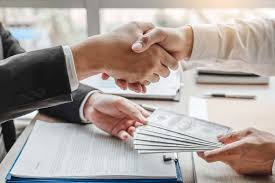

PROBLEM STATEMENT

The bank wants to decide whether to give a loan to a person or not. Using details like age, income-related information, and purpose of the loan, we will build a model that predicts if a person is a safe (good) or risky (defaulter) borrower.
So, we will build a model that predicts whether a person is:

0 → Safe (will repay loan)                                                        
1 → Risky (may default)

using their personal and financial details.

DATA DICTIONARY


Feature	Meaning                                                                                    
Age	-  Age of the person                                                            
Sex	Male or Female                                                                
Saving accounts	Amount of savings (little, moderate, rich, etc.)                 
Checking account	Balance in checking account                                                                                                                  
Credit amount	Loan amount taken                                                     
Duration	Loan duration (in months)                                               
Purpose	Reason for loan (car, education, etc.)                                     
Risk	Target variable (0 = safe, 1 = risky)

IMPORTING OF LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

LOADING OF A DATASET

In [12]:
import pandas as pd

df = pd.read_csv("/content/German_Credit-1.csv")
df.head()

,Age,Sex,Saving accounts,Checking account,Credit amount,Duration,Risk,Purpose
0,67,male,little,little,1169,6,0,radio/TV
1,22,female,little,moderate,5951,48,1,radio/TV
2,49,male,little,little,2096,12,0,education
3,45,male,little,little,7882,42,0,furniture/equipment
4,53,male,little,little,4870,24,1,car


DATA OVERVIEW

In [14]:
#df.head() shows the first 5 rows of dataset
df.head()

,Age,Sex,Saving accounts,Checking account,Credit amount,Duration,Risk,Purpose
0,67,male,little,little,1169,6,0,radio/TV
1,22,female,little,moderate,5951,48,1,radio/TV
2,49,male,little,little,2096,12,0,education
3,45,male,little,little,7882,42,0,furniture/equipment
4,53,male,little,little,4870,24,1,car


In [15]:
#df.tail() shows the last values of the dataset given the value we put , here we gave 6 so we are able to see last 6 values
df.tail(6)

,Age,Sex,Saving accounts,Checking account,Credit amount,Duration,Risk,Purpose
994,50,male,little,moderate,2390,12,0,car
995,31,female,little,little,1736,12,0,furniture/equipment
996,40,male,little,little,3857,30,0,car
997,38,male,little,little,804,12,0,radio/TV
998,23,male,little,little,1845,45,1,radio/TV
999,27,male,moderate,moderate,4576,45,0,car


UNDERSTANDING THE SHAPE OF THE DATASET

In [18]:
df.shape  #This shows the total Rows and Columns the datset has

(1000, 8)

DATA TYPE ANALYSIS

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Saving accounts   1000 non-null   object
 3   Checking account  1000 non-null   object
 4   Credit amount     1000 non-null   int64 
 5   Duration          1000 non-null   int64 
 6   Risk              1000 non-null   int64 
 7   Purpose           1000 non-null   object
dtypes: int64(4), object(4)
memory usage: 62.6+ KB


OBERVATIONS :                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  The dataset contains both numerical and categorical variables.                       
Numerical: Age, Credit Amount, Duration                                                                          
Categorical: Sex, Saving accounts, Checking account, Purpose                        
Some columns contain categorical values, so they need to be converted into     numbers before applying machine learning models.                                 
There may be missing values in columns like saving accounts or checking account, which need to be handled.                                               
The target variable Risk is binary:
0 → Safe customer
1 → Risky customer                                                               
The dataset appears to be structured and clean, but preprocessing (like encoding and handling missing values) is required.                                     
Features like credit amount and duration may strongly influence whether a person is risky or not.                                                                               

DUPLICATE DATA CHECK

In [21]:
df.duplicated().sum()  #It shows total duplicate values , here it ho 0 upliate values

np.int64(0)

STATISTICAL SUMMARY

In [22]:
df.describe()

,Age,Credit amount,Duration,Risk
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,3271.258000,20.903000,0.300000
std,11.375469,2822.736876,12.058814,0.458487
min,19.000000,250.000000,4.000000,0.000000
25%,27.000000,1365.500000,12.000000,0.000000
50%,33.000000,2319.500000,18.000000,0.000000
75%,42.000000,3972.250000,24.000000,1.000000
max,75.000000,18424.000000,72.000000,1.000000


Observations

Mean value for the age column is approx 35 and the median is 33. This shows that majority of the customers are under 35 years of age.
Mean amount of credit is approx 3,271 but it has a wide range with values from 250 to 18,424. We will explore this further in univariate analysis.
Mean duration for which the credit is given is approx 21 months.

EXTRACTING CATEGORICAL VALUES

In [23]:
cat_col = ["Sex", "Saving accounts", "Checking account", "Purpose", "Risk"]

for col in cat_col:
    print(col)
    print(df[col].value_counts())
    print()

Sex
Sex
male      690
female    310
Name: count, dtype: int64

Saving accounts
Saving accounts
little        786
moderate      103
quite rich     63
rich           48
Name: count, dtype: int64

Checking account
Checking account
moderate    472
little      465
rich         63
Name: count, dtype: int64

Purpose
Purpose
car                    337
radio/TV               280
furniture/equipment    181
business                97
education               59
repairs                 22
domestic appliances     12
vacation/others         12
Name: count, dtype: int64

Risk
Risk
0    700
1    300
Name: count, dtype: int64



OBSERVATIONS :


1.More male customers than female

2.We can see that the distribution of classes in the target variable is imbalanced i.e., only 30% observations with defaulters.


3.Most of the customers are not at risk

EXPLORATORY DATA ANALYSIS

UNIVARIATE ANALYSIS

In [26]:
 import matplotlib.pyplot as plt
 import seaborn as sns


In [27]:
def simple_plot(data, column):
    plt.figure(figsize=(10,5))

    # Histogram
    plt.subplot(1,2,1)
    sns.histplot(data[column], bins=10)
    plt.title(column + " Histogram")

    # Boxplot
    plt.subplot(1,2,2)
    sns.boxplot(x=data[column])
    plt.title(column + " Boxplot")

    plt.show()

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
#To create labeled Barplot

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
def labeled_barplot(data, column):
    plt.figure(figsize=(8,5))

    ax = sns.countplot(x=data[column], palette="Paired")

    # Add values on top of bars
    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x() + p.get_width()/2, height, int(height),
                ha='center', va='bottom')

    plt.title(column + " Count")
    plt.xticks(rotation=45)
    plt.show()

OBSERVATIONS

AGE

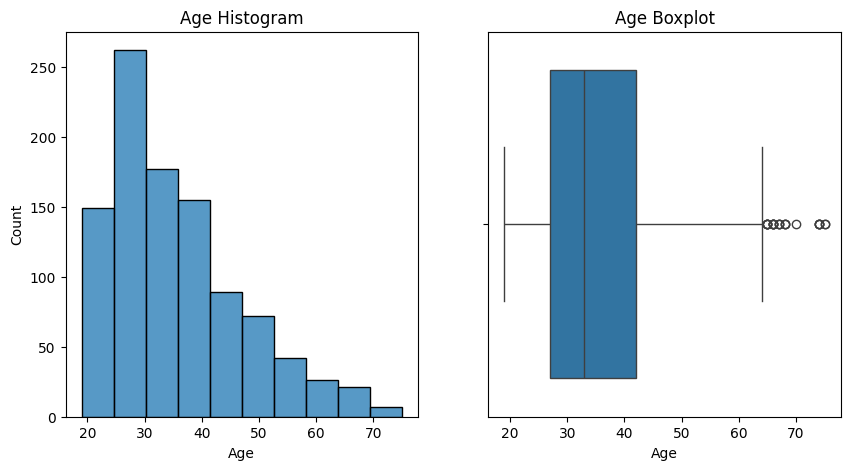

In [33]:
simple_plot(df, "Age")

The distribution of age is right-skewed                                                      
The boxplot shows that there are outliers at the right end                                     
We will not treat these outliers as they represent the real market trend

CREDIT AMOUNT

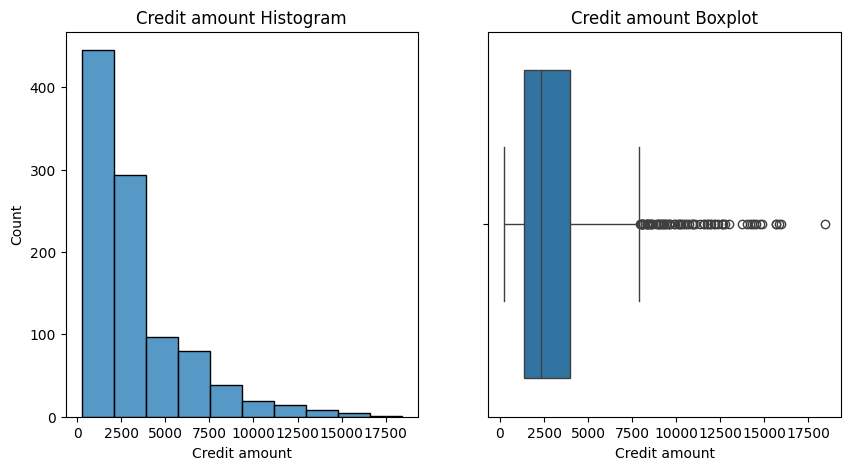

In [35]:
simple_plot(df, "Credit amount")